# 导入库

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib import rcParams
rcParams["font.family"] = ["Microsoft YaHei"]

# 数据处理

In [2]:
df = pd.read_csv("Cars Datasets.csv",encoding='cp1252')
df.head()

,ï»¿Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",Hybrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   ï»¿Company Names           1218 non-null   str  
 1   Cars Names                 1218 non-null   str  
 2   Engines                    1218 non-null   str  
 3   CC/Battery Capacity        1215 non-null   str  
 4   HorsePower                 1218 non-null   str  
 5   Total Speed                1218 non-null   str  
 6   Performance(0 - 100 )KM/H  1212 non-null   str  
 7   Cars Prices                1218 non-null   str  
 8   Fuel Types                 1218 non-null   str  
 9   Seats                      1218 non-null   str  
 10  Torque                     1217 non-null   str  
dtypes: str(11)
memory usage: 104.8 KB


In [4]:
# 数据预处理

df.rename(columns={"ï»¿Company Names":"Company Names"}, inplace=True)

df['CC/Battery Capacity'] = df['CC/Battery Capacity'].str.replace(",","")

df.rename(columns={'HorsePower':'Horse Power (hp)'}, inplace=True)
df['Horse Power (hp)'] = df['Horse Power (hp)'].str.extract(r"([\d.]+) ").astype(float)

df.rename(columns={'Total Speed':'Total Speed (km/h)'}, inplace=True)
df['Total Speed (km/h)'] = df['Total Speed (km/h)'].str.extract(r"([\d.]+) ").astype(float)

df.rename(columns={'Performance(0 - 100 )KM/H':'Performance(0 - 100 )KM/H (sec)'}, inplace=True)
df['Performance(0 - 100 )KM/H (sec)'] = df['Performance(0 - 100 )KM/H (sec)'].str.extract(r"([\d.]+) ").astype(float)

df.rename(columns={'Torque':'Torque (Nm)'}, inplace=True)

In [5]:
cat_cols = ["Company Names", "Cars Names", "Engines","CC/Battery Capacity", "Fuel Types"]
for col in cat_cols:
    df[col] = df[col].astype('category')

df["Seats"] = pd.to_numeric(df["Seats"], errors="coerce").astype("Int64")

df.rename(columns={'Torque':'Torque (Nm)'}, inplace=True)

In [6]:
df.rename(columns={'Cars Prices':'Cars Prices ($)'}, inplace=True)
def clean_price(x):
    if pd.isna(x): 
        return None
    x = str(x).replace(",", "").replace("$", "").strip()
    nums = [float(i) for i in re.findall(r"\d+\.?\d*", x)]
    if not nums:
        return None
    return sum(nums)/len(nums)
df['Cars Prices ($)'] = df['Cars Prices ($)'].apply(clean_price)
df['Torque (Nm)'] = df['Torque (Nm)'].apply(clean_price)

In [7]:
# 处理缺失值

df.isna().sum()
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [8]:
# 处理重复值
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [9]:
# 处理异常值
def remove_outliers_multiple(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        low = Q1 - 1.5 * IQR
        high = Q3 + 1.5 * IQR
        df = df[(df[col] >= low) & (df[col] <= high)]
    return df
num_cols = ["Cars Prices ($)", "Horse Power (hp)"]
df = remove_outliers_multiple(df, num_cols)

# 可视化

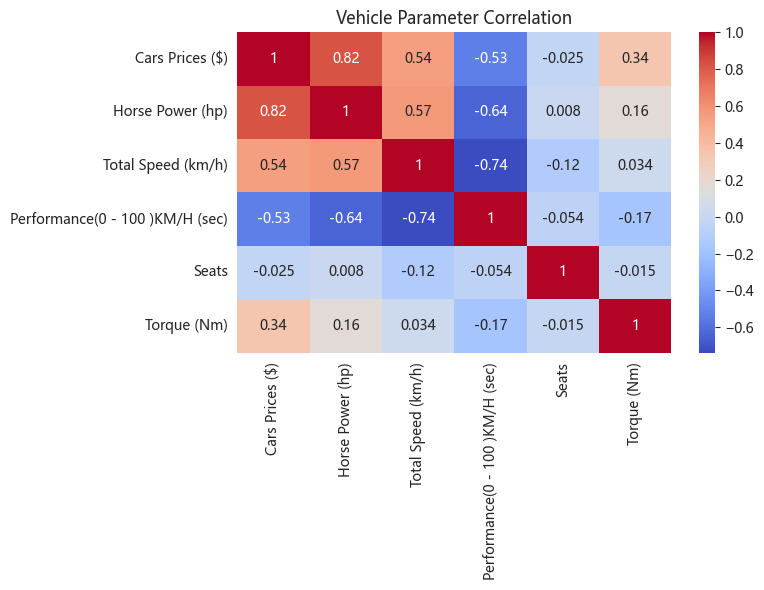

In [10]:
# 汽车特征相关性热力图

a = df[['Cars Prices ($)',
        "Horse Power (hp)",
        'Total Speed (km/h)',
        'Performance(0 - 100 )KM/H (sec)',
        "Seats",
        "Torque (Nm)"
        ]].corr() 
a['Cars Prices ($)'].sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.heatmap(a, cmap="coolwarm",annot=True)
plt.title("Vehicle Parameter Correlation")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of Car Prices')

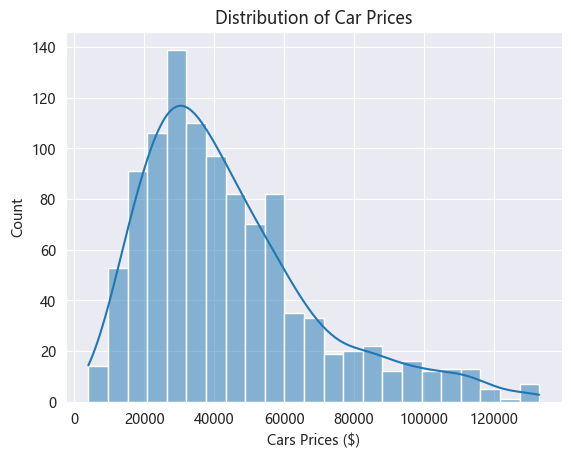

In [11]:
# 汽车价格的核密度估计图
sns.histplot(data=df,x="Cars Prices ($)",kde=True)
plt.title("Distribution of Car Prices")

Text(0.5, 1.0, 'Relationship Between Car Price and Horse Power')

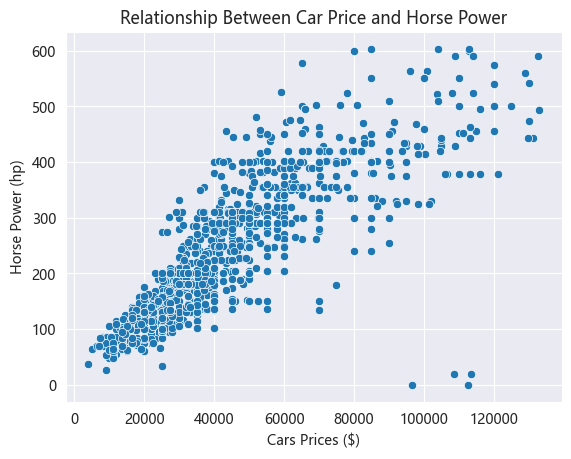

In [12]:
# 汽车马力和价格关系散点图
sns.scatterplot(df,x="Cars Prices ($)",y="Horse Power (hp)")
plt.title("Relationship Between Car Price and Horse Power")

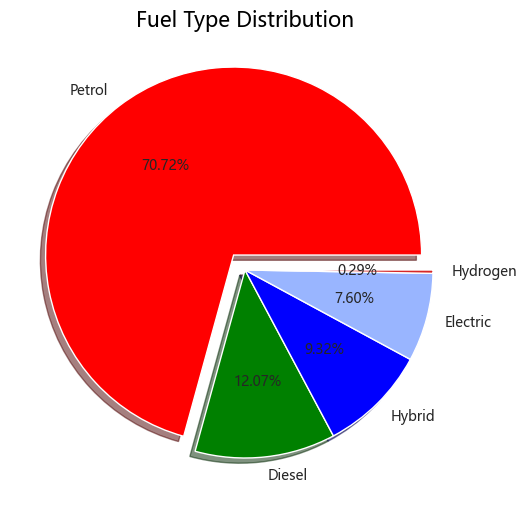

In [13]:
# 车辆能源类型占比

plt.figure(figsize=(8,5))
fuel_counts = df['Fuel Types'].value_counts()
colors = ["red","green","blue","#99b5ff","#d62728"]
explode = [0.1,0,0,0,0] 
plt.pie(fuel_counts,labels=fuel_counts.index,autopct="%1.2f%%",startangle=0,colors=colors,explode=explode,shadow=True)
plt.tight_layout()
plt.title("Fuel Type Distribution",color='black',fontsize=15)
plt.show()

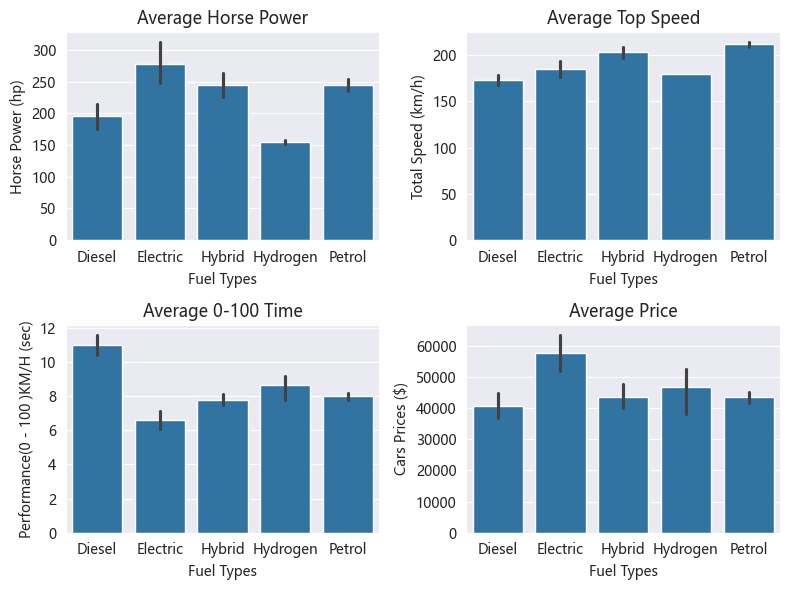

In [14]:
# 不同类型车辆性能对比

fig, axes = plt.subplots(2, 2, figsize=(8,6))
sns.barplot( data=df,x="Fuel Types",y="Horse Power (hp)",ax=axes[0,0])
axes[0,0].set_title("Average Horse Power")

sns.barplot(data=df,x="Fuel Types",y="Total Speed (km/h)",ax=axes[0,1])
axes[0,1].set_title("Average Top Speed")

sns.barplot(data=df,x="Fuel Types",y="Performance(0 - 100 )KM/H (sec)",ax=axes[1,0])
axes[1,0].set_title("Average 0-100 Time")

sns.barplot(data=df,x="Fuel Types",y="Cars Prices ($)",ax=axes[1,1])
axes[1,1].set_title("Average Price")

plt.tight_layout()
plt.show()